In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
from scipy import stats
import NLProcessing
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')

font_path = "fonts"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"
mpl.rcParams['svg.fonttype'] = 'none'

NT_COLORS = {
    'Acetylcholine': '#0072B2',
    'Glutamate': "#E60000",
    'GABA': "#088D4B",
}

In [27]:
specifiedpath = "D:\\"
filepath = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\OSAR_bothresponders_Full_20260617.xlsx"
mbonlist_csv = "MBONlist.csv"
filepath_total = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Totalcomparisonofallmetrics-Full.xlsx"

df = pd.read_excel(filepath)

In [28]:
acr = df[df['responder'] == 'ACR'].set_index('MBON')
chrimson = df[df['responder'] == 'Chrimson2'].set_index('MBON')

acr = acr.drop(index=["R76B09", "VT999036"], errors="ignore")
chrimson = chrimson.drop(index=["R76B09", "VT999036"], errors="ignore")

mbons = acr.index.intersection(chrimson.index)
acr = acr.loc[mbons]
chrimson = chrimson.loc[mbons]

pref_acr = (acr['PI_Hg_OSAR'].abs() + acr['Light Attraction Index_Hg_OSAR'].abs()) / 2
pref_chr = (chrimson['PI_Hg_OSAR'].abs() + chrimson['Light Attraction Index_Hg_OSAR'].abs()) / 2

loco_acr = (acr['Log2 Bout Speed ratio_Hg_OSAR'].abs() + acr['Bout Number Index_Hg_OSAR'].abs() + acr['Bout Duration ratio_Hg_OSAR'].abs() + acr['Max Velocity ratio_Hg_OSAR'].abs()) / 4
loco_chr = (chrimson['Log2 Bout Speed ratio_Hg_OSAR'].abs() + chrimson['Bout Number Index_Hg_OSAR'].abs() + chrimson['Bout Duration ratio_Hg_OSAR'].abs() + chrimson['Max Velocity ratio_Hg_OSAR'].abs()) / 4

lobelocation = NLProcessing.generate_lobelocation(mbons.tolist(), mbonlist_csv)
lobelocation = lobelocation.set_index('MBON').loc[mbons].reset_index()

In [29]:
LABEL_BY = "MBON_number"   # options: "MBON_number"  or  "driver"

if LABEL_BY == "MBON_number":
    _numcol = next((c for c in lobelocation.columns if "number" in c.lower()), None)
    if _numcol is not None:
        _lab = lobelocation.set_index("MBON")[_numcol].astype(str).str.strip().to_dict()
        point_label = {m: (_lab.get(m) or m) for m in mbons}
    else:
        _ml = pd.read_csv(mbonlist_csv)
        def _lookup_number(driver):
            for _, r in _ml.iterrows():
                names = [x.strip() for x in str(r["MBON names"]).replace(".", ",").split(",")]
                if driver in names:
                    return str(r["MBON number"]).strip()
            return driver
        point_label = {m: _lookup_number(m) for m in mbons}
else:
    point_label = {m: m for m in mbons}

# Phenomics

## 2b. Phenomics - Climbing locomotor: GtACR1 vs CsChrimson by NT (Climbing only)

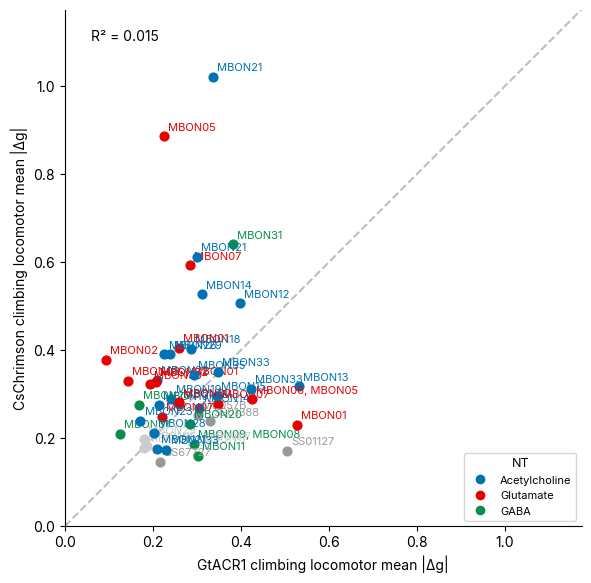

In [25]:
mpl.rcParams['svg.fonttype'] = 'none'

D = chr(0x394)   
_dft = pd.read_excel(specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Climbing_20260617.xlsx")
_dft = _dft[~_dft['MBON'].isin(['VT999036', 'R76B09'])]
loco_cols = [c for c in _dft.columns if D in c
             and not any(x in c for x in ["Fall number", "Pause position", "pausepos", "Speed_"])]

_dft[loco_cols] = _dft[loco_cols].abs()
_dft["locomotor_mean"] = _dft[loco_cols].mean(axis=1)
mbon_loco = _dft.pivot_table(index="MBON", columns="responder", values="locomotor_mean").dropna()

nt_series = lobelocation.set_index('MBON')['Neurotransmitter']

fig, ax = plt.subplots(figsize=(6, 6))
for mbon in mbon_loco.index:
    x, y = mbon_loco.loc[mbon, "ACR"], mbon_loco.loc[mbon, "Chrimson2"]
    color = '#CCCCCC' if (x < 0.2 and y < 0.2) else NT_COLORS.get(nt_series.get(mbon), '#999999')
    ax.scatter(x, y, s=40, color=color, zorder=3)
    ax.annotate(point_label.get(mbon, mbon), (x, y), fontsize=8, ha='left', va='bottom',
                xytext=(3, 3), textcoords='offset points', color=color)

lim = max(mbon_loco["ACR"].max(), mbon_loco["Chrimson2"].max()) * 1.15
ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect('equal')

r2 = stats.pearsonr(mbon_loco["ACR"], mbon_loco["Chrimson2"])[0] ** 2
ax.text(0.05, 0.94, f'R{chr(0x00B2)} = {r2:.3f}', transform=ax.transAxes, fontsize=10)
ax.set_xlabel(f'GtACR1 climbing locomotor mean |{D}g|', fontsize=10)
ax.set_ylabel(f'CsChrimson climbing locomotor mean |{D}g|', fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=NT_COLORS[nt], markersize=8, label=nt) for nt in NT_COLORS]
ax.legend(handles=handles, title='NT', fontsize=8, title_fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "_climbingphenomics for both responders_" + date + ".svg", bbox_inches="tight")
plt.show()

## 4. Combined phenomics (OSAR + Climbing) by NT

In [17]:
df_total_raw = pd.read_excel(filepath_total)
df_total_raw = df_total_raw[~df_total_raw['MBON'].isin(['VT999036', 'R76B09'])]

acr_t = df_total_raw[df_total_raw['responder'] == 'ACR'].set_index('MBON')
chr_t = df_total_raw[df_total_raw['responder'] == 'Chrimson2'].set_index('MBON')
mbons_t = acr_t.index.intersection(chr_t.index)
acr_t = acr_t.loc[mbons_t]
chr_t = chr_t.loc[mbons_t]

locomotor_metrics_OSAR = [
    'Log2 Bout Speed ratio_Hg_OSAR', 'Bout Duration ratio_Hg_OSAR',
    'Bout Number Index_Hg_OSAR', 'Max Velocity ratio_Hg_OSAR',
]
locomotor_metrics_climbing = [
    'Average height climbed_\u0394g_Climbing', 'Straightness Index_\u0394g_Climbing',
    'Bout speed_\u0394g_Climbing', 'Duration of bouts_\u0394g_Climbing',
    'Number of Bouts_\u0394g_Climbing', 'Max velocity_\u0394g_Climbing',
]

osar_acr = acr_t[locomotor_metrics_OSAR].abs().mean(axis=1)
osar_chr = chr_t[locomotor_metrics_OSAR].abs().mean(axis=1)
climb_acr = acr_t[locomotor_metrics_climbing].abs().mean(axis=1)
climb_chr = chr_t[locomotor_metrics_climbing].abs().mean(axis=1)

pref_acr_t = acr_t[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']].abs().mean(axis=1)
pref_chr_t = chr_t[['PI_Hg_OSAR', 'Light Attraction Index_Hg_OSAR']].abs().mean(axis=1)

effect_threshold = 0.35
high_acr = (osar_acr >= effect_threshold) | (climb_acr >= effect_threshold)
high_chr = (osar_chr >= effect_threshold) | (climb_chr >= effect_threshold)

lobelocation_t = NLProcessing.generate_lobelocation(mbons_t.tolist(), mbonlist_csv)
nt_series_t = lobelocation_t.set_index('MBON')['Neurotransmitter']

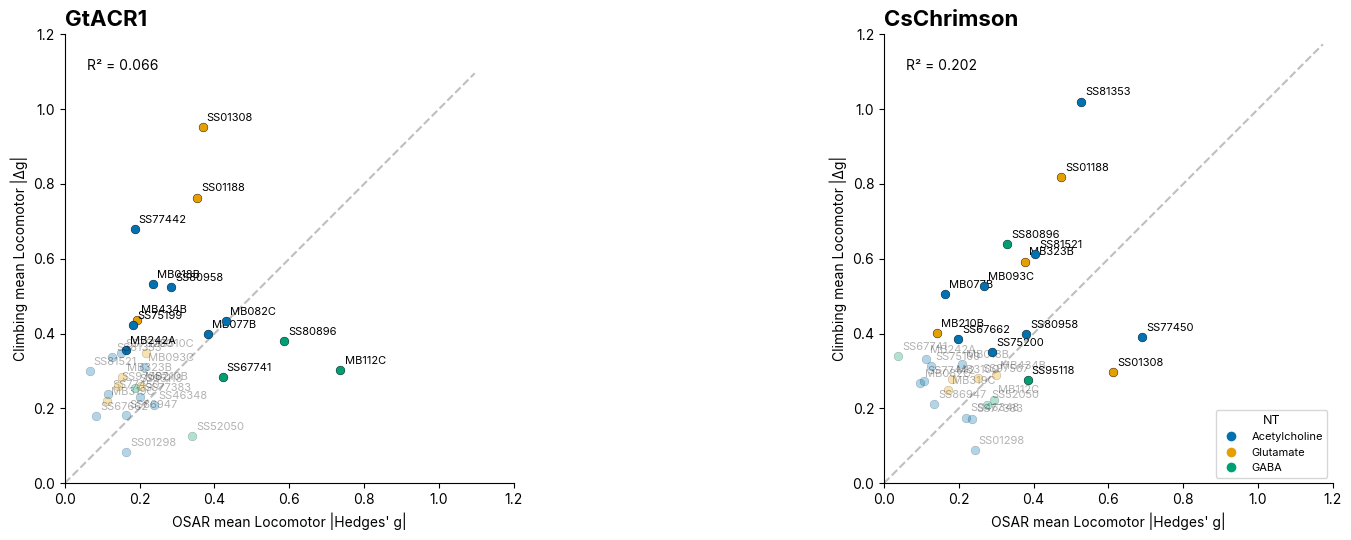

In [14]:
mpl.rcParams['svg.fonttype'] = 'none'

panels = [
    (osar_acr, climb_acr, high_acr, 'GtACR1'),
    (osar_chr, climb_chr, high_chr, 'CsChrimson'),
]

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

for ax, (x, y, mask, title), label in zip(axes, panels, ['A', 'B']):
    for mbon in mbons_t:
        nt = nt_series_t[mbon]
        alpha = 1.0 if mask[mbon] else 0.3
        ax.scatter(x[mbon], y[mbon], s=40, color=NT_COLORS.get(nt, '#999999'), zorder=3, alpha=alpha, edgecolors='k', linewidth=0.3)
        ax.annotate(mbon, (x[mbon], y[mbon]), fontsize=8, ha='left', va='bottom', xytext=(3, 3),
                    textcoords='offset points', alpha=alpha)

    ax.set_xlim(0, 1.2)
    ax.set_ylim(0, 1.2)
    lim = max(x.max(), y.max()) * 1.15
    ax.plot([0, lim], [0, lim], '--', color='gray', alpha=0.5, zorder=1)

    r_squared = stats.pearsonr(x, y)[0] ** 2
    ax.text(0.05, 0.92, f'R\u00b2 = {r_squared:.3f}', transform=ax.transAxes, fontsize=10)

    ax.set_xlabel("OSAR mean Locomotor |Hedges' g|", fontsize=10)
    ax.set_ylabel('Climbing mean Locomotor |\u0394g|', fontsize=10)
    ax.set_title(f'{title}', fontsize=16, fontweight='bold', loc='left')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=NT_COLORS[nt], markersize=8, label=nt) for nt in NT_COLORS]
axes[1].legend(handles=handles, title='NT', fontsize=8, title_fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

# Heatmaps

In [16]:
import textwrap

responder = 'Chrimson2'  # Switch to 'ACR' as needed

totalmetriccomparison = pd.read_excel(filepath)

if responder == 'Chrimson2':
    responderrename = "CsChrimson"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="Chrimson2"].reset_index(drop=True)
    colormap = 'coolwarm'
elif responder == 'ACR':
    responderrename = "GtACR1"
    df_cluster = totalmetriccomparison[totalmetriccomparison['responder']=="ACR"].reset_index(drop=True)
    colormap = 'coolwarm'

df_cluster = df_cluster[~df_cluster['MBON'].isin(['VT999036', 'R76B09'])]


lobelocation_cluster = NLProcessing.generate_lobelocation(df_cluster['MBON'].tolist(), mbonlist_csv)
for n in df_cluster['MBON']:
    df_cluster.loc[df_cluster['MBON'] == n, 'Lobe'] = lobelocation_cluster[lobelocation_cluster['MBON'] == n]['Lobe_location'].values[0]
    df_cluster.loc[df_cluster['MBON'] == n, 'Name'] = lobelocation_cluster[lobelocation_cluster['MBON'] == n]['MBON number'].values[0]
    df_cluster.loc[df_cluster['MBON'] == n, 'NT'] = lobelocation_cluster[lobelocation_cluster['MBON'] == n]['Neurotransmitter'].values[0]

df_cluster_data = df_cluster.drop(columns=['responder', 'Lobe', 'NT', 'Name', 'MBON']).copy()
df_cluster_data.index = df_cluster['MBON']

df_cluster['Name_short'] = df_cluster['Name']
df_cluster['NT_parsed'] = df_cluster['NT'].apply(NLProcessing.parse_nt)
df_cluster['Lobes_parsed'] = df_cluster['Lobe'].apply(NLProcessing.parse_lobes)

nt_palette = {
    'Acetylcholine': '#0072B2',
    'Glutamate': "#FFCD27",
    'GABA': '#009E73',
}

lobe_palette = {'α': "#E60000", "α'": "#F576CB", 'β': "#723D01", "β'": "#B86800", 'γ': '#999999', 'Calyx': '#000000', 'Unknown': '#FFFFFF'}

# Settings
fig_width, fig_height = 5, 10
dendrogram_size = 0.08
gap = 0.02

In [9]:
# Climbing clustermap setup
responder_fall = 'ACR'  # Switch to 'ACR' as needed

filepath_climbing = specifiedpath + "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\2025 Complete raw values osar climbing\\Climbing_20260617.xlsx"
totalmetriccomparison_fall = pd.read_excel(filepath_climbing)

if responder_fall == 'Chrimson2':
    responderrename_fall = "CsChrimson"
    df_cluster_fall = totalmetriccomparison_fall[totalmetriccomparison_fall['responder']=="Chrimson2"].reset_index(drop=True)
    colormap_fall = 'coolwarm'
elif responder_fall == 'ACR':
    responderrename_fall = "GtACR1"
    df_cluster_fall = totalmetriccomparison_fall[totalmetriccomparison_fall['responder']=="ACR"].reset_index(drop=True)
    colormap_fall = 'coolwarm'

df_cluster_fall = df_cluster_fall[~df_cluster_fall['MBON'].isin(['VT999036', 'R76B09'])]

lobelocation_fall = NLProcessing.generate_lobelocation(df_cluster_fall['MBON'].tolist(), mbonlist_csv)
for n in df_cluster_fall['MBON']:
    df_cluster_fall.loc[df_cluster_fall['MBON'] == n, 'Lobe'] = lobelocation_fall[lobelocation_fall['MBON'] == n]['Lobe_location'].values[0]
    df_cluster_fall.loc[df_cluster_fall['MBON'] == n, 'Name'] = lobelocation_fall[lobelocation_fall['MBON'] == n]['MBON number'].values[0]
    df_cluster_fall.loc[df_cluster_fall['MBON'] == n, 'NT'] = lobelocation_fall[lobelocation_fall['MBON'] == n]['Neurotransmitter'].values[0]

df_cluster_data_fall = df_cluster_fall.drop(columns=['genotypeandresponder', 'responder', 'Lobe', 'NT', 'Name', 'MBON']).copy()
df_cluster_data_fall.index = df_cluster_fall['MBON']

df_cluster_fall['Name_short'] = df_cluster_fall['Name']
df_cluster_fall['NT_parsed'] = df_cluster_fall['NT'].apply(NLProcessing.parse_nt)
df_cluster_fall['Lobes_parsed'] = df_cluster_fall['Lobe'].apply(NLProcessing.parse_lobes)
df_cluster_fall2 = df_cluster_fall.copy()

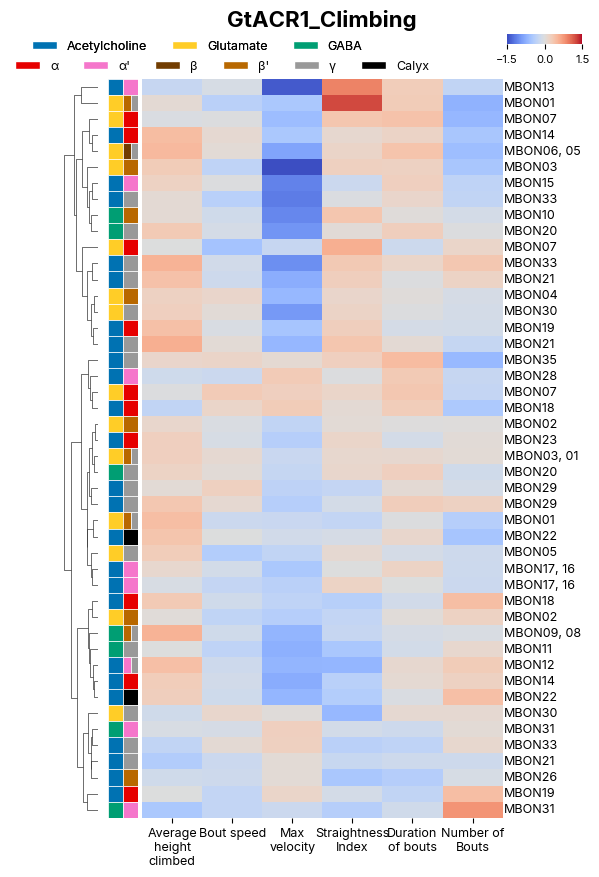

In [10]:
plt.rcParams["font.family"] = "Inter"

df_cluster_fall2 = df_cluster_fall2[['MBON', 'Average height climbed_Δg',
       'Bout speed_Δg', 'Max velocity_Δg','Straightness Index_Δg', 'Duration of bouts_Δg', 'Number of Bouts_Δg','responder', 'genotypeandresponder', 'Lobe',
       'Name', 'NT', 'Name_short', 'NT_parsed', 'Lobes_parsed']]

df_cluster_fall_numeric = df_cluster_fall2[['Average height climbed_Δg',
       'Bout speed_Δg', 'Max velocity_Δg','Straightness Index_Δg', 'Duration of bouts_Δg', 'Number of Bouts_Δg']]
df_cluster_fall_numeric.index = df_cluster_fall2['MBON']

g1 = sns.clustermap(df_cluster_fall_numeric, cmap=colormap, method='complete', metric='euclidean', yticklabels=False, 
                    xticklabels=[col.replace("_Δg", "").replace("_ΔΔ", "") for col in df_cluster_fall_numeric.columns], vmin=-1.5, vmax=1.5,
                    row_cluster=True, col_cluster=False, annot=False,
                    row_colors=['#FFFFFF'] * len(df_cluster_fall_numeric),
                    dendrogram_ratio=(dendrogram_size, dendrogram_size),
                    cbar_kws=dict(orientation='horizontal', ticks=[-1.5, 0, 1.5]), 
                    figsize=(fig_width, fig_height), cbar_pos=(0.92, 0.955, 0.15, 0.010))

cbar = g1.ax_cbar
cbar.tick_params(labelsize=8)

row_order = g1.dendrogram_row.reordered_ind
rc_pos = g1.ax_row_colors.get_position()
hm_pos = g1.ax_heatmap.get_position()
col_w = 0.03

g1.ax_row_colors.set_position([rc_pos.x0 + gap, rc_pos.y0, col_w * 2, rc_pos.height])
g1.ax_heatmap.set_position([hm_pos.x0 + gap + col_w*2 - 0.02, hm_pos.y0, hm_pos.width - col_w*2-0.02, hm_pos.height])

ax_rc = g1.ax_row_colors
ax_rc.clear()
ax_rc.set_xlim(0, 2)
ax_rc.set_ylim(0, len(row_order))
ax_rc.invert_yaxis()
ax_rc.axis('off')

for i, idx in enumerate(row_order):
    nts = df_cluster_fall2['NT_parsed'].iloc[idx]
    n_nts = len(nts) if nts else 1
    for j, nt in enumerate(nts):
        rect = plt.Rectangle((j / n_nts, i), 1 / n_nts, 1, facecolor=nt_palette.get(nt, '#FFFFFF'), edgecolor='white', linewidth=0.5)
        ax_rc.add_patch(rect)
    lobes = df_cluster_fall2['Lobes_parsed'].iloc[idx]
    n_lobes = len(lobes) if lobes else 1
    for j, lobe in enumerate(lobes):
        rect = plt.Rectangle((1 + j / n_lobes, i), 1 / n_lobes, 1, facecolor=lobe_palette.get(lobe, '#FFFFFF'), edgecolor='white', linewidth=0.5)
        ax_rc.add_patch(rect)

g1.ax_heatmap.set_ylabel('')
g1.ax_heatmap.set_xticklabels(g1.ax_heatmap.get_xticklabels(), ha='center', fontsize=9)
NLProcessing.wrap_labels(g1.ax_heatmap, 10)

for i, idx in enumerate(row_order):
    g1.ax_heatmap.text(1.005, i + 0.5, df_cluster_fall2['Name_short'].iloc[idx], ha='left', va='center', fontsize=9, transform=g1.ax_heatmap.get_yaxis_transform())

nt_legend = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor='white', label=l) for l, c in nt_palette.items()]
lobe_legend = [plt.Rectangle((0,0),1,1, facecolor=c, edgecolor='white', label=l) for l, c in lobe_palette.items() if l != 'Unknown']
leg1 = g1.fig.legend(handles=nt_legend, loc='upper center', bbox_to_anchor=(0.30, 0.97), ncol=len(nt_legend), fontsize=9, title_fontsize=9, frameon=False)
g1.fig.add_artist(leg1)
g1.fig.legend(handles=lobe_legend, loc='upper center', bbox_to_anchor=(0.35, 0.95), ncol=len(lobe_legend), fontsize=9, title_fontsize=8, frameon=False)

g1.fig.suptitle(responderrename_fall+ "_Climbing", fontsize=16, x=0.55, y=0.99, fontweight = 'bold')
mpl.rcParams['svg.fonttype'] = 'none'
plt.savefig("D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\osar_compiled\\images\\" + date + "_clustermapofmbonsbynttype_Climbing_" + responder_fall + "_" + date + ".svg", bbox_inches="tight")
plt.show()